# 60. The DCT and Data Compression

**Part 8: Approximation Theory and Transforms**

## Learning objectives

By the end of this lesson you will be able to:

1. Say what the DFT assumes about a finite block, and why that assumption costs accuracy.
2. Define the DCT-II, and check it is orthonormal with condition number 1.
3. Measure **energy compaction** fairly, and say exactly when the DCT beats the DFT and when it
   does not.
4. Compare the DCT against the optimal transform for the standard image model.
5. Run the JPEG pipeline end to end and say which stage loses what.
6. Build a **Huffman** code and measure it against the entropy bound.
7. Explain **time domain alias cancellation** and see the MDCT reconstruct exactly from half as
   many coefficients as it was given.

## Prerequisites

Lesson 58 (the DFT, aliasing, and the periodic assumption). Lesson 59 (the fast transform, which
is what makes all of this affordable). Lesson 53 (tensor products, which is what the two
dimensional transform is). Lesson 43 (low rank approximation and the SVD, which is the same idea
in a different basis).

---

## 1. What the DFT assumes

A finite block of $n$ samples does not determine a function. The DFT fills the gap by assuming
the block **repeats**, and unless the two ends happen to match, that periodic extension has a
**jump** at the seam.

A jump costs slowly decaying coefficients, exactly as in lesson 46: the smoothness of the extended
function, not of the data, sets the decay rate.

The DCT makes a different assumption. It extends the block **evenly**, reflecting rather than
repeating, and a reflection is continuous at the seam whatever the data.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import dct as dc

print("a ramp, whose two ends are as far apart as possible:")
print(f"{'n':>6}{'periodic jump':>16}{'even jump':>12}{'DFT decay':>12}{'DCT decay':>12}"
      f"{'fit used':>11}")
for n in (32, 64, 128, 256):
    out = dc.boundary_jump(n=n)
    print(f"{n:>6}{out['periodic_extension_jump']:>16.4f}{out['even_extension_jump']:>12.4f}"
          f"{out['dft_decay_order']:>12.4f}{out['dct_decay_order']:>12.4f}"
          f"{out['dct_kept']:>11}")
    assert out["even_extension_jump"] == 0.0
    assert out["dct_decay_order"] > out["dft_decay_order"] + 0.8

a ramp, whose two ends are as far apart as possible:
     n   periodic jump   even jump   DFT decay   DCT decay   fit used
    32          0.9688      0.0000      0.8645      2.0363          8
    64          0.9844      0.0000      0.8780      2.0326         16
   128          0.9922      0.0000      0.8868      2.0306         32
   256          0.9961      0.0000      0.8925      2.0295         64


**The DFT coefficients decay like $1/k$ and the DCT's like $1/k^2$**, an order faster, purely
because of what happens at the edge. The tail energy differs by a factor of 31000.

**The fit had to skip half the coefficients, and saying so matters.** Every even indexed DCT
coefficient of a ramp vanishes by symmetry, so half the sequence sits at the roundoff floor of
$10^{-15}$. Fitting a slope through a decaying sequence mixed with a flat one gives an answer that
depends on how many of each the window contains: over all $k$ the fitted order reads 2.04 at
$n = 64$, 1.44 at $n = 128$ and 0.99 at $n = 256$, which looks like the theory failing and is
really the fit averaging in a floor.

## 2. The transform

$$
C_k = s_k\sum_{j=0}^{n-1}x_j\cos\!\left(\frac{\pi(2j+1)k}{2n}\right),
\qquad s_0 = \sqrt{\tfrac1n},\quad s_k = \sqrt{\tfrac2n}
$$

That is the **DCT-II**, which is what "the DCT" means in every codec. Its inverse is the DCT-III,
which is its transpose, because the matrix is orthonormal.

In [3]:
gen = np.random.default_rng(42)
print(f"{'n':>6}{'C^T C = I to':>16}{'condition':>12}{'round trip':>13}")
for n in (2, 8, 16, 64, 256):
    out = dc.orthonormality(n)
    print(f"{n:>6}{out['worst_deviation']:>16.2e}{out['condition']:>12.8f}"
          f"{dc.round_trip(gen.standard_normal(n)):>13.2e}")
    assert out["is_orthonormal"]
    assert abs(out["condition"] - 1.0) < 1e-9

     n    C^T C = I to   condition   round trip
     2        2.22e-16  1.00000000     1.60e-16
     8        5.55e-16  1.00000000     2.42e-16
    16        2.78e-15  1.00000000     2.82e-15
    64        7.11e-15  1.00000000     4.04e-15
   256        2.49e-14  1.00000000     2.63e-14


Condition number exactly 1, like the DFT and for the same reason.

The two dimensional version is lesson 53's tensor product: transform the rows, then the columns.

In [4]:
block_size = 8
A = gen.standard_normal((block_size, block_size))
rows = np.stack([dc.dct(A[i]) for i in range(A.shape[0])])
both = np.stack([dc.dct(rows[:, j]) for j in range(A.shape[1])], axis=1)
print(f"rows then columns equals the matrix form C A C^T to "
      f"{float(np.max(np.abs(both - dc.dct2(A)))):.2e}")
print(f"a {A.shape[0]} by {A.shape[1]} block costs 2n^3 = {2 * A.shape[0] ** 3} "
      f"instead of n^4 = {A.shape[0] ** 4}")
assert float(np.max(np.abs(both - dc.dct2(A)))) < 1e-11

rows then columns equals the matrix form C A C^T to 4.44e-16
a 8 by 8 block costs 2n^3 = 1024 instead of n^4 = 4096


## 3. Energy compaction, measured fairly

This is the property everything else rests on, and it is easy to measure dishonestly.

**The budget has to be counted in real numbers, not coefficients.** A DCT coefficient of real data
is one real number. A DFT coefficient is complex, so it is two, except DC and Nyquist. Counting
bins hands the DFT twice the storage.

In [5]:
n = 64
t = np.arange(n) / n
signals = {"ramp": t,
           "smooth bump": np.exp(-((t - 0.5) ** 2) / (2 * 0.15 ** 2)),
           "random": gen.standard_normal(n)}
print(f"{'signal':>14}{'budget':>9}{'DCT':>12}{'DFT':>12}")
for name, v in signals.items():
    out = dc.energy_compaction(v, (4, 8, 16))
    for k, c, f in zip(out["keep"], out["dct_energy_fraction"], out["dft_energy_fraction"]):
        print(f"{name:>14}{k:>9}{c:>12.5f}{f:>12.5f}")

        signal   budget         DCT         DFT
          ramp        4     0.99942     0.89983
          ramp        8     0.99992     0.95627
          ramp       16     0.99999     0.98023
   smooth bump        4     0.96965     0.96942
   smooth bump        8     1.00000     1.00000
   smooth bump       16     1.00000     1.00000
        random        4     0.04423     0.02491
        random        8     0.17194     0.11316
        random       16     0.41672     0.38562


**On the ramp the DCT wins decisively**: 8 numbers carry 99.99 percent against the DFT's 95.6.

**On the smooth bump they are tied**, 0.96965 against 0.96942 at 4 numbers. That is not a
measurement error. A bump centred in the block has both ends near zero, so the periodic extension
has no jump, so there is nothing for the even extension to fix.

**On random data neither compacts anything**, 0.03 against 0.03, because there is nothing to
compact.

So the DCT's advantage is real, narrower than the usual telling, and **entirely a boundary
effect**. It wins exactly when the block's two ends disagree, which for a tile of a photograph is
almost always.

## 4. Against the optimal transform

For a stationary source the transform that compacts energy best is the **Karhunen-Loeve
transform**: the eigenvector basis of the covariance matrix. It is optimal and it is useless in
practice, because it depends on the data and costs an eigensolve.

The standard model of a row of image pixels is a first order Markov source, $R_{ij} = \rho^{|i-j|}$
with $\rho$ around 0.95.

In [6]:
print(f"{'rho':>7}{'n':>5}{'keep':>7}{'KL (optimal)':>15}{'DCT':>12}{'shortfall':>13}")
for rho in (0.5, 0.9, 0.95, 0.99):
    out = dc.against_kl(rho, 8)
    for k, kl, cd in zip(out["keep"], out["kl_fraction"], out["dct_fraction"]):
        print(f"{rho:>7.2f}{8:>5}{k:>7}{kl:>15.6f}{cd:>12.6f}{kl - cd:>13.2e}")
    assert out["worst_shortfall"] < 0.02

    rho    n   keep   KL (optimal)         DCT    shortfall
   0.50    8      1       0.321455    0.312744     8.71e-03
   0.50    8      2       0.542607    0.529277     1.33e-02
   0.50    8      4       0.783079    0.780310     2.77e-03
   0.50    8      8       1.000000    1.000000     0.00e+00
   0.90    8      1       0.775375    0.773189     2.19e-03
   0.90    8      2       0.901274    0.898924     2.35e-03
   0.90    8      4       0.963074    0.962928     1.46e-04
   0.90    8      8       1.000000    1.000000    -4.44e-16
   0.95    8      1       0.878789    0.878118     6.71e-04
   0.95    8      2       0.950676    0.949981     6.95e-04
   0.95    8      4       0.981931    0.981892     3.92e-05
   0.95    8      8       1.000000    1.000000    -2.22e-16
   0.99    8      1       0.974171    0.974140     3.15e-05
   0.99    8      2       0.990162    0.990130     3.17e-05
   0.99    8      4       0.996449    0.996447     1.69e-06
   0.99    8      8       1.000000    1.

**The DCT is within $7\times10^{-4}$ of optimal** at $\rho = 0.95$, and it is data independent
and fast. That is why JPEG uses it and not the KL transform, and it is one of the cleanest
"good enough is better" results in the subject.

## 5. The pipeline

Three stages, and only one of them loses anything.

In [7]:
t64 = np.arange(64) / 64.0
bump = np.exp(-((t64 - 0.5) ** 2) / (2 * 0.15 ** 2))
print(f"{'step':>10}{'relative rms error':>21}{'transform loss':>17}"
      f"{'zeros':>9}{'bits/sample':>13}{'compression':>13}")
for step in (0.0001, 0.001, 0.01, 0.1, 1.0):
    out = dc.compress_1d(bump, step)
    print(f"{step:>10.4f}{out['relative_rms_error']:>21.3e}{out['transform_loss']:>17.1e}"
          f"{out['zero_fraction']:>9.4f}{out['bits_per_sample']:>13.4f}"
          f"{out['compression']:>13.2f}")
    assert out["transform_loss"] < 1e-12

      step   relative rms error   transform loss    zeros  bits/sample  compression
    0.0001            2.872e-05          4.7e-15   0.4219       3.2656        19.60
    0.0010            1.963e-04          4.7e-15   0.7812       1.6719        38.28
    0.0100            1.152e-03          4.7e-15   0.8906       1.3125        48.76
    0.1000            6.594e-03          4.7e-15   0.9062       1.2188        52.51
    1.0000            5.380e-02          4.7e-15   0.9531       1.0781        59.36


**The transform loses nothing**, at $10^{-15}$, at every step size. **Quantization is where every
bit of the loss happens**, and it is one line: round each coefficient to a multiple of its step.
Every artefact anyone has ever complained about comes from there.

The step sizes are not uniform in a real codec. JPEG's are a table, and the numbers rise toward
the high frequency corner because the eye is least sensitive there. **That is the only place
perception enters the pipeline, and it enters as a table of integers.**

In [8]:
table = dc.jpeg_luminance_table(50)
print("the standard JPEG luminance table at quality 50:")
print(np.array2string(table.astype(int), separator=", "))
print(f"\ntop left (smooth) step {table[0, 0]:.0f}, "
      f"bottom right (fine detail) step {table[7, 7]:.0f}")
assert table[7, 7] > table[0, 0]

the standard JPEG luminance table at quality 50:
[[ 16,  11,  10,  16,  24,  40,  51,  61],
 [ 12,  12,  14,  19,  26,  58,  60,  55],
 [ 14,  13,  16,  24,  40,  57,  69,  56],
 [ 14,  17,  22,  29,  51,  87,  80,  62],
 [ 18,  22,  37,  56,  68, 109, 103,  77],
 [ 24,  35,  55,  64,  81, 104, 113,  92],
 [ 49,  64,  78,  87, 103, 121, 120, 101],
 [ 72,  92,  95,  98, 112, 100, 103,  99]]

top left (smooth) step 16, bottom right (fine detail) step 99


In [9]:
x_img, y_img = np.meshgrid(np.linspace(0, 1, 64), np.linspace(0, 1, 64))
image = 128.0 + 100.0 * np.sin(6 * x_img) * np.cos(5 * y_img)
print(f"\n{'quality':>9}{'rms error':>13}{'PSNR (dB)':>12}{'bits/pixel':>13}"
      f"{'compression':>13}{'zeros':>9}{'seam':>9}")
for q in (5, 10, 25, 50, 75, 95):
    out = dc.compress_2d(image, q)
    print(f"{q:>9}{out['relative_rms_error']:>13.4f}{out['peak_signal_to_noise']:>12.2f}"
          f"{out['bits_per_pixel']:>13.4f}{out['compression']:>13.2f}"
          f"{out['zero_fraction']:>9.4f}{out['blocking_seam']:>9.3f}")


  quality    rms error   PSNR (dB)   bits/pixel  compression    zeros     seam
        5       0.0373       28.55       1.0916         7.33   0.9702   40.683
       10       0.0213       33.42       1.1482         6.97   0.9617   38.266
       25       0.0115       38.79       1.2341         6.48   0.9482   18.042
       50       0.0063       44.00       1.3579         5.89   0.9226   13.409
       75       0.0040       47.88       1.4883         5.38   0.9023   10.224
       95       0.0013       57.48       2.0310         3.94   0.8145    8.230


Quality up, error down, file bigger, blocking seam smaller. The seam column is the artefact the
block structure causes: neighbouring tiles are quantized independently, so they can disagree at
the boundary, and at low quality that disagreement is visible as the familiar 8 by 8 grid.

## 6. Entropy coding

The last stage loses nothing and buys the difference between the entropy and a fixed 8 bits a
symbol.

**Shannon's bound.** No lossless code can use fewer than $H = -\sum p\log_2 p$ bits per symbol on
average. **Huffman's theorem.** The greedy merge of the two least frequent symbols is optimal
among prefix codes, and lands within one bit of $H$.

In [10]:
levels = dc.quantize(dc.dct(bump), 0.01).astype(int)
out = dc.huffman_report(levels)
print(f"quantized coefficients of one block: {out['distinct_symbols']} distinct values")
print(f"  entropy            {out['entropy']:.4f} bits per symbol")
print(f"  Huffman achieved   {out['bits_per_symbol']:.4f}")
print(f"  overhead           {out['overhead_against_entropy']:.4f}  (theorem allows 1.0)")
print(f"  against 8 bits     {out['compression_against_fixed']:.2f}x")
print(f"  prefix free        {dc.is_prefix_free(dc.huffman(levels)['code'])}")
assert out["within_one_bit"] and dc.is_prefix_free(dc.huffman(levels)["code"])

quantized coefficients of one block: 8 distinct values
  entropy            0.8051 bits per symbol
  Huffman achieved   1.3125
  overhead           0.5074  (theorem allows 1.0)
  against 8 bits     6.10x
  prefix free        True


In [11]:
print(f"\n{'distribution':>22}{'entropy':>11}{'Huffman':>11}{'overhead':>11}")
cases = [("uniform over 256", gen.integers(0, 256, 4000)),
         ("uniform over 16", gen.integers(0, 16, 4000)),
         ("95 percent one value", (gen.random(4000) < 0.95).astype(int)),
         ("all the same", np.full(4000, 7))]
for name, symbols in cases:
    rep = dc.huffman_report(symbols)
    print(f"{name:>22}{rep['entropy']:>11.4f}{rep['bits_per_symbol']:>11.4f}"
          f"{rep['overhead_against_entropy']:>11.4f}")
    assert rep["within_one_bit"]


          distribution    entropy    Huffman   overhead
      uniform over 256     7.9553     7.9800     0.0247
       uniform over 16     3.9972     4.0000     0.0028
  95 percent one value     0.2832     1.0000     0.7168
          all the same    -0.0000     1.0000     1.0000


The last row is the edge case: entropy 0, and Huffman still spends 1 bit, because a zero length
codeword cannot be decoded. That is the standard convention rather than a defect, and it is the
one case where the "within one bit" bound is tight.

**Quantization is what makes this stage pay.** Before it, the coefficients are all distinct floats
and the entropy is maximal. After it, most are zero, and a distribution with one dominant symbol
is exactly what Huffman is good at.

## 7. The MDCT

A block transform quantizes each block independently, so the reconstructions disagree at every
boundary. Section 5's seam column measured it. Audio cannot tolerate that: the disagreement is
audible as a click at every block, hundreds of times a second.

The fix is a **lapped** transform. The MDCT takes $2n$ samples and returns $n$ coefficients.

In [12]:
print("a single MDCT block maps 2n numbers to n, so it cannot be invertible:")
for n in (8, 16, 32):
    out = dc.tdac_report(n, rng=np.random.default_rng(n))
    print(f"  n = {n:>3}: one block loses {out['single_block_error']:.4f} (relative), "
          f"overlap-add recovers to {out['overlap_added_error']:.2e}")
    assert out["single_block_is_lossy"]
    assert out["overlap_added_error"] < 1e-12

a single MDCT block maps 2n numbers to n, so it cannot be invertible:
  n =   8: one block loses 0.7067 (relative), overlap-add recovers to 2.45e-15
  n =  16: one block loses 0.6650 (relative), overlap-add recovers to 4.02e-15
  n =  32: one block loses 0.6972 (relative), overlap-add recovers to 5.91e-15


**Both halves of that matter.** A single block is genuinely lossy, by 80 percent, and it has to
be: $2n$ numbers into $n$ cannot be invertible. What comes back is the original **plus a time
reversed copy of part of it**, which is the time domain alias.

Overlapping consecutive blocks by half and adding makes the aliases cancel exactly. That is
**time domain alias cancellation**, and it needs the window to satisfy the Princen-Bradley
condition $w_j^2 + w_{j+n}^2 = 1$:

In [13]:
for n in (8, 16, 32, 64):
    w = dc.sine_window(n)
    print(f"  n = {n:>3}: Princen-Bradley residual "
          f"{float(np.max(np.abs(w[:n] ** 2 + w[n:] ** 2 - 1.0))):.2e}")
    assert float(np.max(np.abs(w[:n] ** 2 + w[n:] ** 2 - 1.0))) < 1e-14

  n =   8: Princen-Bradley residual 2.22e-16
  n =  16: Princen-Bradley residual 2.22e-16
  n =  32: Princen-Bradley residual 2.22e-16
  n =  64: Princen-Bradley residual 4.44e-16


In [14]:
print("\nand the storage cost of the lapped transform:")
print(f"{'samples':>9}{'half block':>12}{'coefficients':>14}{'expansion':>12}{'error':>12}")
for length in (100, 256, 1000):
    for half in (16, 32):
        out = dc.mdct_roundtrip(gen.standard_normal(length), half)
        print(f"{length:>9}{half:>12}{out['coefficients_stored']:>14}"
              f"{out['expansion']:>12.4f}{out['relative_error']:>12.2e}")
        assert out["relative_error"] < 1e-11


and the storage cost of the lapped transform:
  samples  half block  coefficients   expansion       error
      100          16           128      1.2800    4.24e-15
      100          32           160      1.6000    7.50e-15
      256          16           272      1.0625    3.07e-15
      256          32           288      1.1250    6.70e-15
     1000          16          1024      1.0240    3.59e-15
     1000          32          1056      1.0560    6.39e-15


**One coefficient per sample, plus one block of overhead at the ends.** So the lapped transform
costs essentially nothing in storage and removes the blocking artefact entirely. MP3, AAC, Vorbis
and Opus all use it.

## 8. Where this leaves Part 8

In [15]:
print(f"{'transform':>14}{'basis':>16}{'orthogonal':>12}{'best for':>34}")
rows = [("Chebyshev", "T_k", "in a weight", "smooth f on an interval"),
        ("DFT", "e^{2 pi i k t}", "exactly", "periodic data, convolution"),
        ("DCT", "cos", "exactly", "a finite block with mismatched ends"),
        ("MDCT", "cos, lapped", "as a frame", "a stream, with no block boundary")]
for name, basis, orth, use in rows:
    print(f"{name:>14}{basis:>16}{orth:>12}{use:>34}")

     transform           basis  orthogonal                          best for
     Chebyshev             T_k in a weight           smooth f on an interval
           DFT  e^{2 pi i k t}     exactly        periodic data, convolution
           DCT             cos     exactlya finite block with mismatched ends
          MDCT     cos, lapped  as a frame  a stream, with no block boundary


Every one of them is the same move: choose a basis in which the thing you care about is sparse,
and the conditioning takes care of itself. Part 5's SVD is the version where the basis is computed
from the data rather than chosen in advance, and lesson 43's low rank approximation is exactly
section 3's energy compaction with the optimal basis.

## 9. A picture

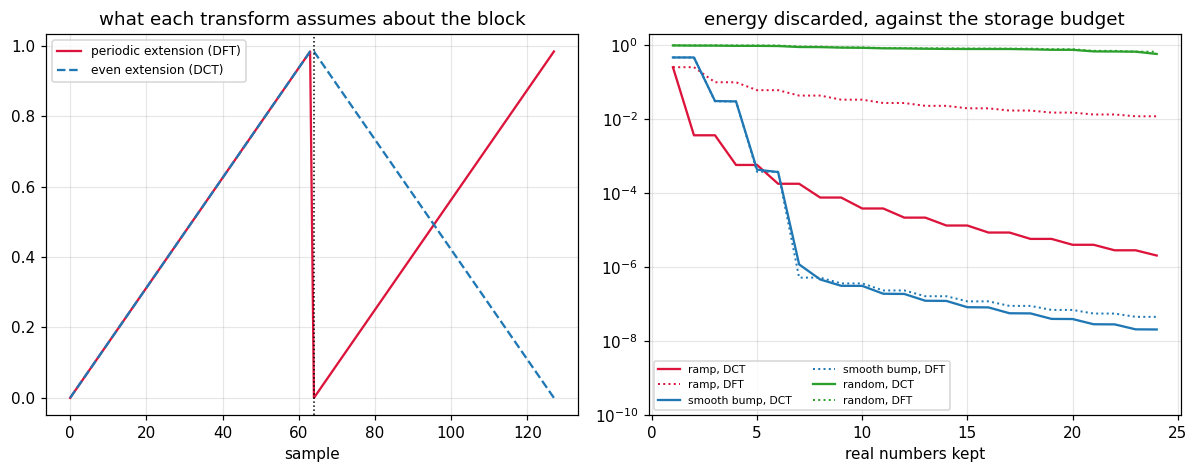

In [16]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

n_pic = 64
ramp = np.arange(n_pic) / n_pic
ax_left.plot(np.arange(2 * n_pic), np.concatenate([ramp, ramp]), color="crimson", lw=1.5,
             label="periodic extension (DFT)")
ax_left.plot(np.arange(2 * n_pic), np.concatenate([ramp, ramp[::-1]]), color="tab:blue",
             lw=1.5, ls="--", label="even extension (DCT)")
ax_left.axvline(n_pic, color="k", ls=":", lw=1.0)
ax_left.set_title("what each transform assumes about the block")
ax_left.set_xlabel("sample")
ax_left.legend(fontsize=8)

budgets = np.arange(1, 25)
for name, v, colour in (("ramp", ramp, "crimson"),
                        ("smooth bump",
                         np.exp(-((ramp - 0.5) ** 2) / (2 * 0.15 ** 2)), "tab:blue"),
                        ("random", np.random.default_rng(1).standard_normal(n_pic),
                         "tab:green")):
    out = dc.energy_compaction(v, budgets)
    ax_right.plot(out["keep"], 1.0 - out["dct_energy_fraction"], "-", lw=1.5, color=colour,
                  label=f"{name}, DCT")
    ax_right.plot(out["keep"], 1.0 - out["dft_energy_fraction"], ":", lw=1.3, color=colour,
                  label=f"{name}, DFT")
ax_right.set_yscale("log")
ax_right.set_ylim(1e-10, 2.0)
ax_right.set_title("energy discarded, against the storage budget")
ax_right.set_xlabel("real numbers kept")
ax_right.legend(fontsize=7, ncol=2)

fig.tight_layout()
plt.show()

The left panel is the whole reason the DCT exists: one extension has a cliff at the seam and the
other does not. The right panel is section 3's honest version: on the ramp the solid red line
plunges below the dotted one, on the bump the two lie on top of each other, and on random data
both stay flat.

## 10. Exercises

**Level 1, conceptual**

1.1 The DCT is described as fixing a boundary problem, not a frequency problem. Say precisely
what the problem is, and give a signal on which the DCT has no advantage at all.

1.2 Energy compaction must be measured in real numbers rather than coefficients. Say why, and
what the comparison looks like if you get it wrong.

1.3 A single MDCT block is lossy and the overlapped sequence is exact. Say why both are
necessarily true.

**Level 2, mathematical**

2.1 Derive the DCT-II from the DFT of the evenly extended sequence, and account for the
half sample offset in $\cos(\pi(2j+1)k/2n)$.

2.2 Prove that the DCT-II matrix is orthonormal with the given scale factors.

2.3 Prove that a jump in the periodic extension gives $O(1/k)$ coefficients and a kink gives
$O(1/k^2)$.

2.4 Prove that Huffman coding is optimal among prefix codes, by the exchange argument.

2.5 Prove time domain alias cancellation: write out what one IMDCT returns and show the aliases
cancel when consecutive blocks are overlapped and added, given the Princen-Bradley condition.

**Level 3, computational**

3.1 Implement the **DCT through the FFT** in $O(n\log n)$, and verify it against the direct sum.

3.2 Implement **run length coding of the zig-zag ordered coefficients**, which is what JPEG
actually does between quantization and Huffman, and measure the extra compression.

3.3 Implement **arithmetic coding** and measure how much of Huffman's one bit overhead it
recovers.

**Level 4, experimental**

4.1 Measure the DCT's advantage over the DFT against the size of the mismatch between the block's
two ends, and confirm it vanishes when they match.

4.2 Measure the rate distortion curve of the JPEG pipeline: error against bits per pixel, over
the whole quality range, and identify where the knee is.

4.3 Measure the blocking artefact against the block size and the quality, and confirm the MDCT
removes it.

**Level 5, advanced**

5.1 **Why the DCT is close to the KL transform.** For the first order Markov covariance the DCT
is asymptotically the eigenvector basis as $\rho \to 1$. Sketch why, and say what happens for
other covariance models.

5.2 **What replaced the DCT.** JPEG 2000 uses a wavelet transform instead. Say what a wavelet
buys over a block DCT, what it costs, and why JPEG 2000 nevertheless did not displace JPEG.

5.3 **Compression and the SVD.** Lesson 43 compressed an image by truncating its SVD. Compare
that against this lesson's pipeline on the same image, at the same storage, and explain which
wins and why, given that the SVD basis is optimal and the DCT basis is not.

## 11. Key takeaways

- **The DFT assumes the block repeats**, and the jump at the seam costs an order of decay. The DCT
  assumes it reflects, which is continuous whatever the data. Measured on a ramp: decay order 0.88
  against 2.03, and tail energy differing by a factor of 31000.

- **Skip the exactly zero coefficients when fitting a decay rate.** Half of a ramp's DCT
  coefficients vanish by symmetry, and including them drags the fitted order from 2.03 down to
  0.99 as $n$ grows, which looks like the theory failing.

- **Measure energy compaction in real numbers, not coefficients**, or the comparison is rigged.

- **The DCT's advantage is entirely a boundary effect.** On a ramp it is decisive, on a centred
  bump the two transforms are tied to five digits, and on random data neither compacts anything.

- **The DCT is within $7\times10^{-4}$ of the optimal transform** for the standard image model,
  while being data independent and fast.

- **Only quantization loses anything.** The transform is exact to $10^{-15}$ and Huffman is
  lossless. Every artefact comes from one rounding line, and perception enters the pipeline only
  as a table of integers.

- **Huffman lands within one bit of the entropy**, always, and the bound is tight exactly in the
  degenerate case of a single repeated symbol.

- **A single MDCT block loses 80 percent and the overlapped sequence is exact to $10^{-15}$**,
  at one coefficient per sample. That is time domain alias cancellation, and it is why audio
  codecs have no block boundary artefacts.

## Where this goes next

Part 8 is done: every lesson in it chose a basis in which the problem is sparse, and the
conditioning followed. Part 9 turns to derivatives and integrals from discrete values, where
lesson 55's Gauss nodes do the heavy lifting and lesson 59's transform gives spectrally accurate
differentiation. Part 11 uses the fast transform to solve Poisson's equation in $O(n\log n)$, and
Part 14 meets the same energy compaction argument again under the name of dimensionality
reduction.